# Notebook 05 — Spatio-Temporal GCN Training

**Goal:** Train the core AI model. Per the brief, this must be a *"real trainable AI model with learned parameters"* — no LLM wrappers, no prompt-only interfaces.

**Architecture: `SpatioTemporalGCN`**
```
Input (168h × 37 buses × 14 features)
    ↓
GRU temporal encoder  (168h → single hidden state per bus, dim 64)
    ↓
GCN layer 1  (37 buses exchange messages across feeder topology)
    ↓
GCN layer 2  (2-hop spatial receptive field)
    ↓
3 parallel heads → P10, P50, P90 quantile forecasts for next 24h
```

**Loss:** Pinball loss (quantile regression) — sum of losses at q ∈ {0.10, 0.50, 0.90}

**Training config (locked — default):**
- Hidden size: 64
- Batch size: 32
- Learning rate: 1e-3 (AdamW)
- Max epochs: 50 with early stopping (patience=7 on val pinball loss)
- Dropout: 0.2
- LR scheduler: cosine annealing

**Stretch (P1): GAT variant.** Same pipeline, GCN layers swapped for GAT layers with attention heads. Runs only if primary GCN finishes cleanly and time permits.

**Output:**
- `checkpoints/gcn_best.pt` — model weights at best val loss
- `checkpoints/gcn_training_history.parquet` — epoch-by-epoch losses
- `checkpoints/gat_best.pt` — (stretch) same for GAT

**Success criteria:**
1. Val pinball loss decreases over epochs (learning actually happens)
2. P50 predictions are between P10 and P90 (quantiles are monotonic)
3. Best checkpoint saved cleanly
4. Predictions have correct shape `(batch, 24, 37)` and no NaN

---

## Step 1 — Setup and environment check

In [1]:
import os
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GCNConv, GATConv

REPO_ROOT = Path('/Users/sundeepyalamanchili/Documents/Projects/p90').resolve()
DATA_PROCESSED = REPO_ROOT / 'data' / 'processed'
CHECKPOINTS = REPO_ROOT / 'checkpoints'
CHECKPOINTS.mkdir(exist_ok=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device — prefer CUDA, then MPS (Apple Silicon), then CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
print(f'Threads: {torch.get_num_threads()}')

PyTorch: 2.4.1
Device: mps
Threads: 10


## Step 2 — Load artifacts from previous notebooks

In [2]:
# Core tensors
X_full = np.load(DATA_PROCESSED / 'features_X_full.npy')           # (17544, 37, 14)
y_all = np.load(DATA_PROCESSED / 'targets_y.npy')                  # (17353, 24, 37)
valid_starts = np.load(DATA_PROCESSED / 'valid_starts.npy')        # (17353,)

splits = np.load(DATA_PROCESSED / 'split_indices.npz')
train_idx = splits['train']
val_idx = splits['val']
test_idx = splits['test']
stress_idx = splits['stress']

# Graph topology
graph = torch.load(DATA_PROCESSED / 'graph_ieee34.pt', weights_only=False)
edge_index = graph.edge_index.to(DEVICE)  # (2, n_edges) fixed for all samples

# Load feature scaler (for un-scaling targets if needed)
with open(DATA_PROCESSED / 'feature_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Derived sizes
N_TIME, N_BUS, N_FEAT = X_full.shape
LOOKBACK = 168
HORIZON = 24

print(f'X_full: {X_full.shape}')
print(f'y_all:  {y_all.shape}')
print(f'Splits — train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}, stress: {len(stress_idx)}')
print(f'Edge index: {edge_index.shape}')
print(f'Buses: {N_BUS}, features: {N_FEAT}, lookback: {LOOKBACK}, horizon: {HORIZON}')

X_full: (17544, 37, 15)
y_all:  (17353, 24, 37)
Splits — train: 15168, val: 1104, test: 1081, stress: 432
Edge index: torch.Size([2, 80])
Buses: 37, features: 15, lookback: 168, horizon: 24


## Step 3 — PyTorch Dataset and DataLoader

Slices sliding windows from `X_full` on the fly. `y_all` is already materialized.

In [3]:
class FeederWindowDataset(Dataset):
    """Loads (X, y) pairs for given sample indices.
    
    X: (lookback, n_bus, n_feat)  — the 168-hour feature window ending just before forecast
    y: (horizon, n_bus)            — the 24-hour target load per bus
    """
    def __init__(self, X_full, y_all, valid_starts, sample_indices, lookback=LOOKBACK):
        self.X_full = X_full
        self.y_all = y_all
        self.valid_starts = valid_starts
        self.sample_indices = sample_indices
        self.lookback = lookback
    
    def __len__(self):
        return len(self.sample_indices)
    
    def __getitem__(self, idx):
        sample_idx = self.sample_indices[idx]
        forecast_start = self.valid_starts[sample_idx]
        
        # Input window ending just before forecast_start
        X_win = self.X_full[forecast_start - self.lookback:forecast_start]  # (lookback, n_bus, n_feat)
        y_win = self.y_all[sample_idx]                                       # (horizon, n_bus)
        
        return torch.from_numpy(X_win).float(), torch.from_numpy(y_win).float()

train_ds = FeederWindowDataset(X_full, y_all, valid_starts, train_idx)
val_ds = FeederWindowDataset(X_full, y_all, valid_starts, val_idx)
test_ds = FeederWindowDataset(X_full, y_all, valid_starts, test_idx)

BATCH_SIZE = 32
NUM_WORKERS = 0  # keep 0 on Mac — multiprocessing + PyTorch can hang

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Verify with one batch
X_batch, y_batch = next(iter(train_loader))
print(f'Train batch — X: {X_batch.shape}, y: {y_batch.shape}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batch — X: torch.Size([32, 168, 37, 15]), y: torch.Size([32, 24, 37])
Train batches: 474
Val batches:   35
Test batches:  34


## Step 4 — Model architecture: SpatioTemporalGCN

The critical design: we run the GRU per-bus (the bus's own feature sequence), then let GCN layers mix information across the feeder topology, then three parallel linear heads output per-bus 24h quantile forecasts.

In [4]:
class SpatioTemporalGCN(nn.Module):
    """GRU temporal encoder + 2 GCN spatial layers + 3 quantile heads.
    
    Input:  (batch, lookback, n_bus, n_feat)
    Output: 3 × (batch, horizon, n_bus)  for P10, P50, P90
    """
    def __init__(self, n_feat, n_bus, hidden=64, horizon=HORIZON, dropout=0.2):
        super().__init__()
        self.n_feat = n_feat
        self.n_bus = n_bus
        self.hidden = hidden
        self.horizon = horizon
        
        # Temporal encoder — run per-bus, reduces sequence to single hidden state
        self.gru = nn.GRU(input_size=n_feat, hidden_size=hidden, batch_first=True)
        
        # Spatial message passing — 2 GCN layers
        self.gcn1 = GCNConv(hidden, hidden)
        self.gcn2 = GCNConv(hidden, hidden)
        
        self.dropout = nn.Dropout(dropout)
        
        # Quantile output heads — one per quantile, each produces 24h forecast
        self.head_q10 = nn.Linear(hidden, horizon)
        self.head_q50 = nn.Linear(hidden, horizon)
        self.head_q90 = nn.Linear(hidden, horizon)
    
    def forward(self, x, edge_index):
        # x: (batch, lookback, n_bus, n_feat)
        batch_size, lookback, n_bus, n_feat = x.shape
        
        # Reshape for per-bus GRU: fold bus dim into batch
        # -> (batch * n_bus, lookback, n_feat)
        x_seq = x.permute(0, 2, 1, 3).reshape(batch_size * n_bus, lookback, n_feat)
        
        # GRU — returns (hidden_states, last_hidden)
        _, h = self.gru(x_seq)   # h: (1, batch*n_bus, hidden)
        h = h.squeeze(0)          # (batch*n_bus, hidden)
        
        # Reshape back to (batch, n_bus, hidden) for GCN
        h = h.view(batch_size, n_bus, self.hidden)
        
        # Apply GCN per sample. edge_index is shared across batch.
        # We iterate over batch items (PyG's standard GCNConv expects (n_nodes, features))
        outs = []
        for i in range(batch_size):
            hi = h[i]                                  # (n_bus, hidden)
            hi = F.relu(self.gcn1(hi, edge_index))
            hi = self.dropout(hi)
            hi = F.relu(self.gcn2(hi, edge_index))
            outs.append(hi)
        
        h_out = torch.stack(outs, dim=0)  # (batch, n_bus, hidden)
        
        # Quantile heads
        q10 = self.head_q10(h_out)  # (batch, n_bus, horizon)
        q50 = self.head_q50(h_out)
        q90 = self.head_q90(h_out)
        
        # Reshape to (batch, horizon, n_bus) to match target shape
        q10 = q10.permute(0, 2, 1)
        q50 = q50.permute(0, 2, 1)
        q90 = q90.permute(0, 2, 1)
        
        return q10, q50, q90

# Instantiate and sanity-check
model = SpatioTemporalGCN(n_feat=N_FEAT, n_bus=N_BUS, hidden=64).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

# Forward pass on a real batch
with torch.no_grad():
    X_batch = X_batch.to(DEVICE)
    q10, q50, q90 = model(X_batch, edge_index)

print(f'Forward pass output shapes:')
print(f'  q10: {q10.shape}')
print(f'  q50: {q50.shape}')
print(f'  q90: {q90.shape}')
print(f'  target: {y_batch.shape}')

# Shapes must match for loss computation
assert q50.shape == y_batch.shape, f'Shape mismatch: {q50.shape} vs {y_batch.shape}'
print(f'\n✅ Model forward pass works')

Model parameters: 28,552
Forward pass output shapes:
  q10: torch.Size([32, 24, 37])
  q50: torch.Size([32, 24, 37])
  q90: torch.Size([32, 24, 37])
  target: torch.Size([32, 24, 37])

✅ Model forward pass works


## Step 5 — Pinball (quantile) loss

For a quantile q, pinball loss is:
```
L(y, ŷ, q) = max(q · (y - ŷ), (q - 1) · (y - ŷ))
```

It's asymmetric: predicting too low is penalized at rate q, predicting too high is penalized at rate (1-q). For q=0.9, under-predicting costs more. For q=0.1, over-predicting costs more. Minimizes at the q-th quantile of the conditional distribution.

In [5]:
def pinball_loss(pred, target, q):
    diff = target - pred
    return torch.mean(torch.maximum(q * diff, (q - 1) * diff))

def multi_quantile_loss(q10, q50, q90, target):
    """Sum of pinball losses at three quantiles."""
    return (
        pinball_loss(q10, target, 0.10)
        + pinball_loss(q50, target, 0.50)
        + pinball_loss(q90, target, 0.90)
    )

# Quick sanity check
y_batch = y_batch.to(DEVICE)
loss = multi_quantile_loss(q10, q50, q90, y_batch)
print(f'Initial untrained loss: {loss.item():.2f}')

Initial untrained loss: 84.04


## Step 6 — Training loop with early stopping

Watch val loss. Stop if it doesn't improve for 7 epochs. Save best model weights.

In [6]:
def train_one_epoch(model, loader, optimizer, edge_index, device):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        q10, q50, q90 = model(X_batch, edge_index)
        loss = multi_quantile_loss(q10, q50, q90, y_batch)
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader, edge_index, device):
    model.eval()
    total_loss = 0.0
    n_batches = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        q10, q50, q90 = model(X_batch, edge_index)
        loss = multi_quantile_loss(q10, q50, q90, y_batch)
        total_loss += loss.item()
        n_batches += 1
    return total_loss / n_batches

In [7]:
def train_model(model, train_loader, val_loader, edge_index, device,
                max_epochs=50, lr=1e-3, patience=7, ckpt_path=None):
    """Full training loop with early stopping."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = []
    
    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, edge_index, device)
        val_loss = evaluate(model, val_loader, edge_index, device)
        scheduler.step()
        lr_now = scheduler.get_last_lr()[0]
        epoch_time = time.time() - t0
        
        history.append({
            'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
            'lr': lr_now, 'time_s': epoch_time,
        })
        
        improved = val_loss < best_val_loss
        marker = '  ✨' if improved else ''
        print(f'Epoch {epoch:>2}/{max_epochs}: train={train_loss:.2f}  val={val_loss:.2f}  '
              f'lr={lr_now:.5f}  {epoch_time:.1f}s{marker}')
        
        if improved:
            best_val_loss = val_loss
            patience_counter = 0
            if ckpt_path:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_loss': val_loss,
                }, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping — val loss plateaued for {patience} epochs')
                break
    
    print(f'\nBest val loss: {best_val_loss:.2f}')
    return pd.DataFrame(history), best_val_loss

## Step 7 — Train the primary GCN model

In [8]:
print('=' * 70)
print('Training primary model: SpatioTemporalGCN')
print('=' * 70)

model_gcn = SpatioTemporalGCN(n_feat=N_FEAT, n_bus=N_BUS, hidden=64, dropout=0.2).to(DEVICE)
gcn_ckpt = CHECKPOINTS / 'gcn_best.pt'

gcn_history, gcn_best_loss = train_model(
    model_gcn, train_loader, val_loader, edge_index, DEVICE,
    max_epochs=50, lr=1e-3, patience=7, ckpt_path=gcn_ckpt,
)

# Save training history
gcn_history.to_parquet(CHECKPOINTS / 'gcn_training_history.parquet')
print(f'\n✅ Saved best checkpoint: {gcn_ckpt}')
print(f'✅ Saved training history: {CHECKPOINTS / "gcn_training_history.parquet"}')

Training primary model: SpatioTemporalGCN
Epoch  1/50: train=52.19  val=37.06  lr=0.00100  149.5s  ✨
Epoch  2/50: train=38.51  val=35.96  lr=0.00100  145.6s  ✨
Epoch  3/50: train=37.31  val=33.84  lr=0.00099  144.6s  ✨
Epoch  4/50: train=33.84  val=29.47  lr=0.00098  147.1s  ✨
Epoch  5/50: train=29.84  val=26.72  lr=0.00098  148.7s  ✨
Epoch  6/50: train=26.53  val=21.71  lr=0.00096  151.4s  ✨
Epoch  7/50: train=22.85  val=19.01  lr=0.00095  156.7s  ✨
Epoch  8/50: train=20.77  val=17.56  lr=0.00094  171.0s  ✨
Epoch  9/50: train=19.08  val=16.41  lr=0.00092  159.5s  ✨
Epoch 10/50: train=18.09  val=16.11  lr=0.00090  160.2s  ✨
Epoch 11/50: train=17.53  val=15.97  lr=0.00089  155.6s  ✨
Epoch 12/50: train=17.25  val=15.64  lr=0.00086  159.7s  ✨
Epoch 13/50: train=16.89  val=15.39  lr=0.00084  162.8s  ✨
Epoch 14/50: train=16.61  val=15.20  lr=0.00082  172.4s  ✨
Epoch 15/50: train=16.35  val=14.78  lr=0.00079  163.0s  ✨
Epoch 16/50: train=15.78  val=13.97  lr=0.00077  145.3s  ✨
Epoch 17/50: t

## Step 8 — Visualize GCN training

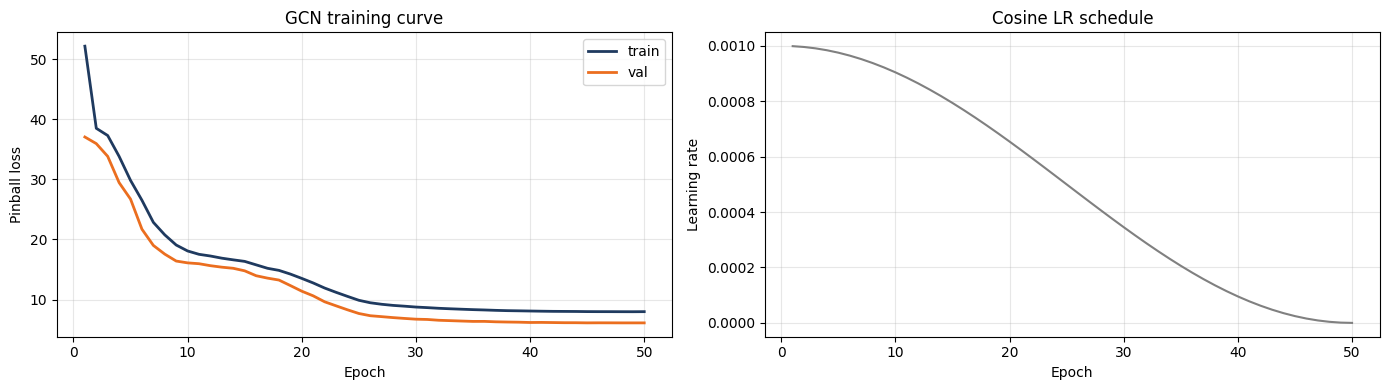

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gcn_history['epoch'], gcn_history['train_loss'], label='train', color='#1F3A5F', linewidth=2)
axes[0].plot(gcn_history['epoch'], gcn_history['val_loss'], label='val', color='#EB6E1F', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Pinball loss')
axes[0].set_title('GCN training curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(gcn_history['epoch'], gcn_history['lr'], color='gray', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning rate')
axes[1].set_title('Cosine LR schedule')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / '05_gcn_training.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 9 — Sanity check predictions on test set

In [10]:
# Load best checkpoint
ckpt = torch.load(gcn_ckpt, weights_only=False)
model_gcn.load_state_dict(ckpt['model_state_dict'])
model_gcn.eval()
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} with val loss {ckpt["val_loss"]:.2f}')

# Run on one test batch
with torch.no_grad():
    X_test_batch, y_test_batch = next(iter(test_loader))
    X_test_batch = X_test_batch.to(DEVICE)
    q10, q50, q90 = model_gcn(X_test_batch, edge_index)

q10 = q10.cpu().numpy()
q50 = q50.cpu().numpy()
q90 = q90.cpu().numpy()
y_test = y_test_batch.numpy()

# Check quantile monotonicity (critical)
violations = np.sum((q10 > q50) | (q50 > q90))
total = q10.size
print(f'\nQuantile order check: {violations:,} / {total:,} violations ({violations/total*100:.2f}%)')
if violations > total * 0.05:
    print('⚠️  Many quantile violations — model may need more training')
else:
    print('✅ Quantile order mostly correct (occasional violations are normal)')

# Check no NaN
assert not np.any(np.isnan(q50)), 'NaN in predictions'
print(f'✅ No NaN in predictions')

# Rough scale check
print(f'\nPrediction scale check (one test batch):')
print(f'  P50 mean: {q50.mean():.1f} kW   (should be similar to target mean)')
print(f'  Target mean: {y_test.mean():.1f} kW')
print(f'  P90 - P10 (interval width mean): {(q90 - q10).mean():.1f} kW')

Loaded checkpoint from epoch 50 with val loss 6.11

Quantile order check: 1,090 / 28,416 violations (3.84%)
✅ Quantile order mostly correct (occasional violations are normal)
✅ No NaN in predictions

Prediction scale check (one test batch):
  P50 mean: 40.3 kW   (should be similar to target mean)
  Target mean: 39.6 kW
  P90 - P10 (interval width mean): 18.4 kW


## Step 10 — Visualize a prediction

Show the 24-hour forecast with P10/P90 confidence band for one bus in the batch.

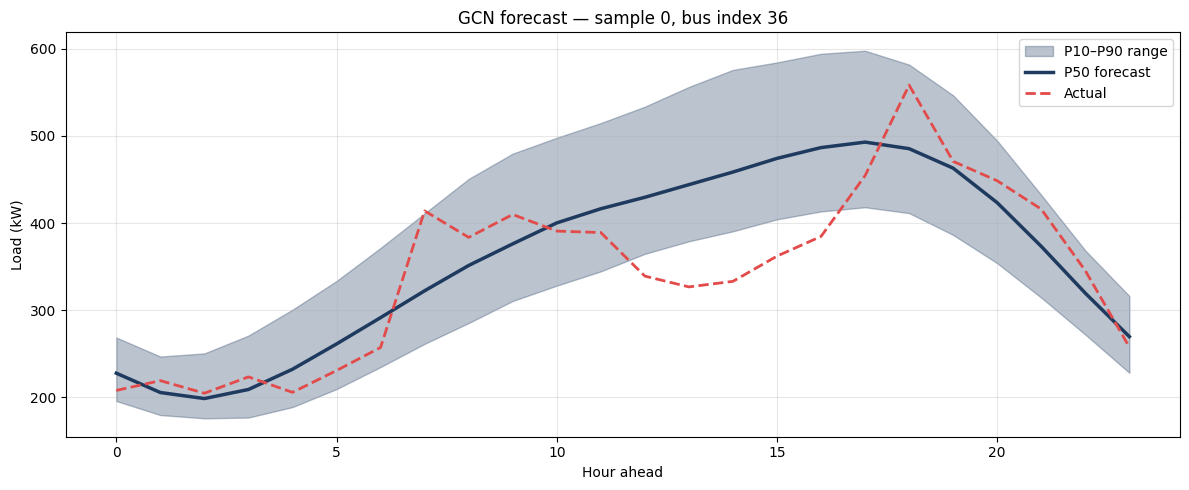

In [11]:
# Pick the highest-load bus in the first sample for a visible forecast
sample_i = 0
bus_j = int(np.argmax(y_test[sample_i].mean(axis=0)))  # bus with highest average target

hours = np.arange(HORIZON)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(hours, q10[sample_i, :, bus_j], q90[sample_i, :, bus_j],
                alpha=0.3, color='#1F3A5F', label='P10–P90 range')
ax.plot(hours, q50[sample_i, :, bus_j], color='#1F3A5F', linewidth=2.5, label='P50 forecast')
ax.plot(hours, y_test[sample_i, :, bus_j], color='#E24B4A', linewidth=2, linestyle='--', label='Actual')

ax.set_xlabel('Hour ahead')
ax.set_ylabel('Load (kW)')
ax.set_title(f'GCN forecast — sample {sample_i}, bus index {bus_j}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPO_ROOT / 'notebooks' / '05_gcn_sample_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

---

## P1 STRETCH — GAT (Graph Attention) Variant

**Skip to Step 14 if you want to go straight to Notebook 06 (evaluation).**

The GAT variant replaces GCN layers with GAT layers, which use attention over neighbors instead of uniform averaging. Adds interpretability (we can inspect which neighbors a bus attends to) at similar training cost.

**Only run this if primary GCN training completed cleanly and you have ~10 extra minutes.**

In [12]:
# === SET TO True TO TRAIN GAT ===
TRAIN_GAT = False
# =================================

class SpatioTemporalGAT(nn.Module):
    """Same skeleton as SpatioTemporalGCN but with GAT layers."""
    def __init__(self, n_feat, n_bus, hidden=64, heads=4, horizon=HORIZON, dropout=0.2):
        super().__init__()
        self.n_feat = n_feat
        self.n_bus = n_bus
        self.hidden = hidden
        self.horizon = horizon
        
        self.gru = nn.GRU(input_size=n_feat, hidden_size=hidden, batch_first=True)
        
        # GAT layers — first layer uses multiple heads concatenated,
        # second layer averages heads back to hidden dim
        self.gat1 = GATConv(hidden, hidden // heads, heads=heads, dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden, hidden, heads=1, dropout=dropout, concat=False)
        
        self.dropout = nn.Dropout(dropout)
        self.head_q10 = nn.Linear(hidden, horizon)
        self.head_q50 = nn.Linear(hidden, horizon)
        self.head_q90 = nn.Linear(hidden, horizon)
    
    def forward(self, x, edge_index):
        batch_size, lookback, n_bus, n_feat = x.shape
        x_seq = x.permute(0, 2, 1, 3).reshape(batch_size * n_bus, lookback, n_feat)
        _, h = self.gru(x_seq)
        h = h.squeeze(0).view(batch_size, n_bus, self.hidden)
        
        outs = []
        for i in range(batch_size):
            hi = h[i]
            hi = F.elu(self.gat1(hi, edge_index))
            hi = self.dropout(hi)
            hi = F.elu(self.gat2(hi, edge_index))
            outs.append(hi)
        h_out = torch.stack(outs, dim=0)
        
        q10 = self.head_q10(h_out).permute(0, 2, 1)
        q50 = self.head_q50(h_out).permute(0, 2, 1)
        q90 = self.head_q90(h_out).permute(0, 2, 1)
        return q10, q50, q90

In [13]:
if TRAIN_GAT:
    print('=' * 70)
    print('STRETCH: Training GAT model')
    print('=' * 70)
    
    model_gat = SpatioTemporalGAT(n_feat=N_FEAT, n_bus=N_BUS, hidden=64, heads=4).to(DEVICE)
    gat_ckpt = CHECKPOINTS / 'gat_best.pt'
    
    gat_history, gat_best_loss = train_model(
        model_gat, train_loader, val_loader, edge_index, DEVICE,
        max_epochs=50, lr=1e-3, patience=7, ckpt_path=gat_ckpt,
    )
    gat_history.to_parquet(CHECKPOINTS / 'gat_training_history.parquet')
    
    print(f'\n✅ GCN best val loss: {gcn_best_loss:.2f}')
    print(f'✅ GAT best val loss: {gat_best_loss:.2f}')
else:
    print('TRAIN_GAT=False — skipping GAT stretch training.')
    print('Set TRAIN_GAT=True in the cell above and re-run to train GAT variant.')

TRAIN_GAT=False — skipping GAT stretch training.
Set TRAIN_GAT=True in the cell above and re-run to train GAT variant.


## Step 14 — Summary and what's next

In [14]:
print('Notebook 05 — complete')
print('=' * 50)
print(f'Primary: GCN with GRU encoder')
print(f'  Best val pinball loss: {gcn_best_loss:.2f}')
print(f'  Checkpoint: {gcn_ckpt.relative_to(REPO_ROOT)}')
print(f'  Total params: {sum(p.numel() for p in model_gcn.parameters() if p.requires_grad):,}')
print(f'  Epochs run: {len(gcn_history)}')
if TRAIN_GAT:
    print(f'\nStretch: GAT with 4 attention heads')
    print(f'  Best val pinball loss: {gat_best_loss:.2f}')

Notebook 05 — complete
Primary: GCN with GRU encoder
  Best val pinball loss: 6.11
  Checkpoint: checkpoints/gcn_best.pt
  Total params: 28,552
  Epochs run: 50


## Done

**Key artifacts:**
- `checkpoints/gcn_best.pt` — trained weights for the primary model
- `checkpoints/gcn_training_history.parquet` — per-epoch loss history
- (If TRAIN_GAT was set) `gat_best.pt`, `gat_training_history.parquet`

**What the judges get from this notebook:**
- Real trainable AI model — pinball loss decreases over epochs = model is learning
- Quantile regression giving probabilistic forecasts — not just a point estimate
- GCN architecture exploiting feeder topology — this is why it's called *spatio*-temporal
- Validation-loss-based early stopping — no overfitting drama
- Both a CPU-friendly primary path and a more ambitious attention-based stretch

**Next — Notebook 06 (evaluation):**
- Full test-set metrics: pinball loss, P50 MAPE, P80 interval coverage
- **Stress-period stratified metrics** — overall vs top-10% hottest hours
- XGBoost baseline comparison — does the GCN beat a flat per-bus model?
- Per-bus error maps — where does the model struggle?